# 1 Reading dataset

In [16]:
# import library and read dataset

import pandas as pd

df_reviews = pd.read_csv('IMDB Dataset.csv')
df_reviews.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [17]:
# take a sample of 10000 rows to make processing faster and get imbalance 9000 data
# create imbalance by taking only 9000 positive and 1000 negetive rows

df_positive = df_reviews[df_reviews['sentiment']=='positive'][:9000]
df_negative = df_reviews[df_reviews['sentiment']=='negative'][:1000]


In [18]:
df_reviews_imb = pd.concat([df_positive, df_negative], )
df_reviews_imb.value_counts('sentiment')

sentiment
positive    9000
negative    1000
Name: count, dtype: int64

# 2 Dealing with Imbalance Classes

In [19]:
# make a barplot to show how data is distributed

df_reviews_imb.value_counts('sentiment')

sentiment
positive    9000
negative    1000
Name: count, dtype: int64

<Axes: xlabel='sentiment'>

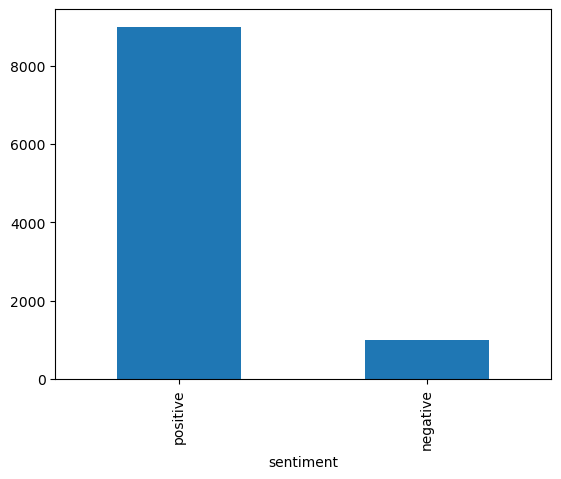

In [20]:
df_reviews_imb.value_counts('sentiment').plot(kind='bar')

## 2.1 Balancing data with .sample()

In [21]:
length_negative = len(df_reviews_imb[df_reviews_imb['sentiment']=='negative'])
length_negative

1000

In [22]:
df_reviews_positive = df_reviews_imb[df_reviews_imb['sentiment']=='positive'].sample(n=length_negative)

In [23]:
df_reviews_negative = df_reviews_imb[df_reviews_imb['sentiment']=='negative']

In [24]:
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])

In [25]:
df_reviews_bal.reset_index(drop=True, inplace=True)
df_reviews_bal

,review,sentiment
0,Never viewed this film until recently on TCM a...,positive
1,I saw this movie on my local cable system unde...,positive
2,Remember that friend in college who always ins...,positive
3,"I heard that after the first Oceans movie, the...",positive
4,There are many people in our lives that we mee...,positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


## 2.2 Balancing data with RandomUnderSampler

In [26]:
#!pip install --upgrade imblearn 

In [27]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=0)

df_review_bal, df_review_bal['sentiment'] = rus.fit_resample(df_reviews_imb[['review']],
                                                             df_reviews_imb['sentiment'])



In [28]:
df_review_bal.value_counts('sentiment')

sentiment
negative    1000
positive    1000
Name: count, dtype: int64

# 3 Splitting data into train and test

In [29]:
# import train_test_split
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_review_bal, test_size=0.33, random_state=42)

In [30]:
train_X, train_y = train['review'], train['sentiment']
test_X, test_y = test['review'], test['sentiment']

In [31]:
train_y

81      negative
915     negative
1018    positive
380     negative
1029    positive
          ...   
1130    positive
1294    positive
860     negative
1459    positive
1126    positive
Name: sentiment, Length: 1340, dtype: object

# 4 Text Representation (Bag of Words)

## 4.1 Count Vectorizer

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

In [33]:
text = ["I love writing code in Python. I love Python code",
        "I have writing code in java. I hate java code"]

In [34]:
df = pd.DataFrame({'review': ['review1', 'review2'], 'text':text})
df

,review,text
0,review1,I love writing code in Python. I love Python code
1,review2,I have writing code in java. I hate java code


In [35]:
cv = CountVectorizer(stop_words='english')
cv_matrix = cv.fit_transform(df['text'])

In [36]:
df_dtm = pd.DataFrame(cv_matrix.toarray(), index=df['review'].values,
                     columns = cv.get_feature_names_out())

In [37]:
df_dtm

,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,1,2,0,0,1


## 4.2 Tfidf

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

text = ["I love writing code in Python. I love Python code",
        "I have writing code in java. I hate java code"]

df = pd.DataFrame({'review': ['review1', 'review2'], 'text':text})

tfidf = TfidfVectorizer(stop_words='english', norm =None)
tfidf_matrix = tfidf.fit_transform(df['text'])

In [39]:
pd.DataFrame(tfidf_matrix.toarray(),  index=df['review'].values,
                     columns = tfidf.get_feature_names_out())

,code,hate,java,love,python,writing
review1,2.0,0.000000,0.00000,2.81093,2.81093,1.0
review2,2.0,1.405465,2.81093,0.00000,0.00000,1.0


# 5 Turn our text data into numberical vectors

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
train_X_vector = tfidf.fit_transform(train_X)
train_X_vector

<1340x20625 sparse matrix of type '<class 'numpy.float64'>'
	with 118834 stored elements in Compressed Sparse Row format>

In [41]:
test_X_vector = tfidf.transform(test_X)
test_X_vector

<660x20625 sparse matrix of type '<class 'numpy.float64'>'
	with 53486 stored elements in Compressed Sparse Row format>

In [42]:
pd.DataFrame.sparse.from_spmatrix(train_X_vector, index=train_X.index,
                                  columns=tfidf.get_feature_names_out())

,00,000,007,01pm,02,04,08,10,100,1000,...,zooming,zooms,zues,zzzzzzzzzzzzzzzzzz,æon,élan,émigré,ísnt,ïn,ünfaithful
81,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1018,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
380,0,0,0,0,0,0,0,0.042791,0,0,...,0,0,0,0,0,0,0,0,0,0
1029,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1294,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1459,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 6 Model Selection

## 6.1 Support Vector Machines (SVM)

In [43]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(train_X_vector, train_y)

SVC(kernel='linear')

In [44]:
print(svc.predict(tfidf.transform(['It was fun to watch'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie'])))

['positive']
['positive']
['negative']


## 6.2 Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_X_vector, train_y)

DecisionTreeClassifier()

## 6.3 Naive Bayes

In [54]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_X_vector.toarray(), train_y)

GaussianNB()

## 6.4 Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(train_X_vector, train_y)

LogisticRegression()

# 7 Model Evaluation

## 7.1 Confusion matrix

In [51]:
# calculate confusion matrix of svc

from sklearn.metrics import confusion_matrix

confusion_matrix(test_y,
                svc.predict(test_X_vector),
                labels=['positive', 'negative'])

array([[290,  45],
       [ 60, 265]], dtype=int64)

## 7.2 Mean Accuracy

In [57]:
# calculate accuracy of all models

print(svc.score(test_X_vector, test_y))
print(dec_tree.score(test_X_vector, test_y))
print(gnb.score(test_X_vector.toarray(), test_y))
print(log_reg.score(test_X_vector, test_y))

0.8409090909090909
0.6590909090909091
0.6348484848484849
0.8303030303030303


## 7.3 F1 Score

In [58]:
from sklearn.metrics import f1_score

f1_score(test_y, svc.predict(test_X_vector),
         labels=['positive', 'negative'],
         average=None)

array([0.84671533, 0.83464567])

## 7.4 Classification report

In [59]:
from sklearn.metrics import classification_report

In [61]:
print(classification_report(test_y,
                      svc.predict(test_X_vector),
                      labels=['positive', 'negative'])
     )

              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



# 8 Tuning the Model

## 8.1 GridSearchCV

In [63]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': [1,4,8,16,32], 'kernel': ['linear', 'rbf']}
svc = SVC()
svc_grid = GridSearchCV(svc, parameters, cv=5)
svc_grid.fit(train_X_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [64]:
svc_grid.best_params_

{'C': 1, 'kernel': 'linear'}

In [65]:
svc_grid.best_estimator_

SVC(C=1, kernel='linear')